In [19]:
path = "/data/big_rim/rsync_dcc_sum/25Nov/2025_10_31/ZIcI1_1mW"

import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from scipy.optimize import least_squares


import os
import pickle
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial import ConvexHull
from scipy.optimize import least_squares



# Your keypoint dictionary
KP = {
    'EarL': 0, 'EarR': 1, 'Snout': 2, 'SpineF': 3, 'SpineM': 4,
    'Tail(base)': 5, 'Tail(mid)': 6, 'Tail(end)': 7,
    'ForepawL': 8, 'WristL': 9, 'ElbowL': 10, 'ShoulderL': 11,
    'ForepawR': 12, 'WristR': 13, 'ElbowR': 14, 'ShoulderR': 15,
    'HindpawL': 16, 'AnkleL': 17, 'KneeL': 18,
    'HindpawR': 19, 'AnkleR': 20, 'KneeR': 21
}


In [ ]:


def analyze_snout_ground_contact(base_path, pred_folder='DANNCE/predict00', 
                                  z_threshold=None):
    """
    Analyze snout-ground proximity and spatial distribution.
    
    Returns:
        dict with snout_z, com_z, contact_frames, contact_locations
    """
    # Load predictions
    pred_path = os.path.join(base_path, pred_folder, 'save_data_AVG.mat')
    pred_3d = sio.loadmat(pred_path)['pred']
    pred_3d = np.squeeze(pred_3d, axis=1)  # (frames, keypoints, 3)
    
    # Load COM
    com_file = os.path.join(base_path, pred_folder, 'com3d_used.mat')
    com_data = sio.loadmat(com_file)
    com = com_data['com']  # (frames, 3)
    
    # Truncate to shorter length
    n_frames = min(len(pred_3d), len(com))
    pred_3d = pred_3d[:n_frames]
    com = com[:n_frames]
    
    print(f"Using {n_frames} frames (pred: {len(sio.loadmat(pred_path)['pred'])}, com: {len(com_data['com'])})")
    
    # Extract snout (KP['Snout'] = 2 in 0-indexed)
    snout_3d = pred_3d[:, KP['Snout'], :]  # (frames, 3)
    
    snout_z = snout_3d[:, 2]
    com_z = com[:, 2]
    
    # Auto-determine threshold if not provided
    # Use mean - 1.5*std as a reasonable default
    if z_threshold is None:
        z_threshold = np.mean(snout_z) - 1.5 * np.std(snout_z)
        print(f"Auto-determined z_threshold: {z_threshold:.2f} mm")
    
    # Find contact frames
    contact_mask = snout_z < z_threshold
    contact_frames = np.where(contact_mask)[0]
    contact_locations = com[contact_mask, :2]  # XY positions during contact
    
    print(f"Found {len(contact_frames)} contact frames ({100*len(contact_frames)/len(snout_z):.1f}% of recording)")
    
    return {
        'snout_z': snout_z,
        'com_z': com_z,
        'snout_xy': snout_3d[:, :2],
        'com_xy': com[:, :2],
        'contact_frames': contact_frames,
        'contact_locations': contact_locations,
        'contact_mask': contact_mask,
        'z_threshold': z_threshold
    }


def plot_snout_analysis(results, base_path, vis_dir='vis'):
    """Three-panel figure showing snout behavior."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Panel 1: Z-height timeseries
    frames = np.arange(len(results['snout_z']))
    axes[0].plot(frames, results['com_z'], label='COM Z', alpha=0.6, linewidth=1)
    axes[0].plot(frames, results['snout_z'], label='Snout Z', alpha=0.8, linewidth=1)
    axes[0].axhline(results['z_threshold'], color='r', ls='--', 
                   label=f'Threshold ({results["z_threshold"]:.1f} mm)')
    
    # Shade contact periods
    axes[0].fill_between(frames, 
                         axes[0].get_ylim()[0], 
                         axes[0].get_ylim()[1], 
                         where=results['contact_mask'],
                         alpha=0.2, color='red', label='Contact')
    
    axes[0].set_xlabel('Frame')
    axes[0].set_ylabel('Z height (mm)')
    axes[0].legend()
    axes[0].set_title('Snout elevation over time')
    axes[0].grid(True, alpha=0.3)
    
    # Panel 2: COM circle with contact locations
    com_xy = results['com_xy']
    contact_xy = results['contact_locations']
    
    # Fit circle to COM path
    hull = ConvexHull(com_xy)
    hx, hy = com_xy[hull.vertices, 0], com_xy[hull.vertices, 1]
    
    # Circle fitting
    init = [hx.mean(), hy.mean(), 
            np.mean(np.hypot(hx - hx.mean(), hy - hy.mean()))]
    
    def residuals(params, xh, yh):
        return np.hypot(xh - params[0], yh - params[1]) - params[2]
    
    res = least_squares(residuals, init, args=(hx, hy))
    xc, yc, r = res.x
    
    # Plot
    axes[1].scatter(com_xy[:, 0], com_xy[:, 1], s=2, alpha=0.2, 
                   c='gray', label='All COM')
    
    if len(contact_xy) > 0:
        axes[1].scatter(contact_xy[:, 0], contact_xy[:, 1], s=20, 
                       c='red', alpha=0.6, label='Snout contact', 
                       edgecolors='darkred', linewidths=0.5)
    
    # Plot fitted circle
    theta = np.linspace(0, 2*np.pi, 200)
    axes[1].plot(xc + r*np.cos(theta), yc + r*np.sin(theta),
                'b-', lw=2, label='Arena boundary', alpha=0.7)
    axes[1].scatter(xc, yc, s=40, color='blue', marker='x', label='Center')
    
    axes[1].set_aspect('equal')
    axes[1].legend()
    axes[1].set_title(f'Spatial distribution of snout contacts (n={len(contact_xy)})')
    axes[1].set_xlabel('X (mm)')
    axes[1].set_ylabel('Y (mm)')
    axes[1].grid(True, alpha=0.3)
    
    # Panel 3: Snout vs COM Z scatter
    scatter = axes[2].scatter(results['com_z'], results['snout_z'], 
                             s=5, alpha=0.4, c=results['contact_mask'], 
                             cmap='RdYlBu_r')
    axes[2].axhline(results['z_threshold'], color='r', ls='--', 
                   label='Threshold')
    axes[2].plot([axes[2].get_xlim()[0], axes[2].get_xlim()[1]], 
                [axes[2].get_xlim()[0], axes[2].get_xlim()[1]], 
                'k--', alpha=0.3, label='Identity')
    axes[2].set_xlabel('COM Z (mm)')
    axes[2].set_ylabel('Snout Z (mm)')
    axes[2].set_title('Snout vs COM elevation')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.suptitle(f'{os.path.basename(base_path)}', fontsize=14, y=1.02)
    plt.tight_layout()
    
    # Save
    save_folder = os.path.join(base_path, vis_dir)
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, 'snout_analysis.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"Saved snout analysis plot to:\n  {save_path}")

In [17]:
   # Run analysis
results = analyze_snout_ground_contact(
    base_path=path,
    pred_folder='DANNCE/predict00',
    z_threshold=None  # Auto-determine, or set to specific value like 15
)

# Create visualization
plot_snout_analysis(results, base_path=path, vis_dir='vis')

# Print some summary stats
print("\n--- Summary Statistics ---")
print(f"Mean snout Z: {np.mean(results['snout_z']):.2f} mm")
print(f"Std snout Z: {np.std(results['snout_z']):.2f} mm")
print(f"Min snout Z: {np.min(results['snout_z']):.2f} mm")
print(f"Mean COM Z: {np.mean(results['com_z']):.2f} mm")
print(f"Contact threshold: {results['z_threshold']:.2f} mm")
print(f"Contact percentage: {100*np.sum(results['contact_mask'])/len(results['contact_mask']):.1f}%")


Using 17000 frames (pred: 17000, com: 17997)
Auto-determined z_threshold: -19.01 mm
Found 1694 contact frames (10.0% of recording)
Saved snout analysis plot to:
  /data/big_rim/rsync_dcc_sum/25Nov/2025_10_31/ZIcI1_1mW/vis/snout_analysis.png

--- Summary Statistics ---
Mean snout Z: 2.93 mm
Std snout Z: 14.62 mm
Min snout Z: -31.12 mm
Mean COM Z: 13.14 mm
Contact threshold: -19.01 mm
Contact percentage: 10.0%


# above code are great, but the edge picking is taking the lead... so have to do something else...

In [6]:
def analyze_snout_ground_contact(base_path, pred_folder='DANNCE/predict00', 
                                  on_table_threshold=0, 
                                  off_edge_threshold=-20):
    """
    Analyze snout-ground proximity using table surface estimated from hindlimbs.
    
    Args:
        on_table_threshold: mm above table surface to count as "sniffing table"
        off_edge_threshold: mm below table surface to count as "peeking off edge"
    
    Returns:
        dict with snout_z, table_z, on_table_mask, off_edge_mask, etc.
    """
    # Load predictions
    pred_path = os.path.join(base_path, pred_folder, 'save_data_AVG.mat')
    pred_3d = sio.loadmat(pred_path)['pred']
    pred_3d = np.squeeze(pred_3d, axis=1)  # (frames, 3, 22) = (frames, xyz, keypoints)
    pred_3d = np.transpose(pred_3d, (0, 2, 1))  # (frames, 22, 3) = (frames, keypoints, xyz)
    
    # Load COM
    com_file = os.path.join(base_path, pred_folder, 'com3d_used.mat')
    com_data = sio.loadmat(com_file)
    com = com_data['com']  # (frames, 3)
    
    # Truncate to shorter length
    n_frames = min(len(pred_3d), len(com))
    pred_3d = pred_3d[:n_frames]
    com = com[:n_frames]
    
    n_keypoints = pred_3d.shape[1]
    print(f"Using {n_frames} frames with {n_keypoints} keypoints")
    
    # Extract snout (using your KP dict)
    snout_3d = pred_3d[:, KP['Snout'], :]  # (frames, 3)
    snout_z = snout_3d[:, 2]
    com_z = com[:, 2]
    
    # Estimate table surface from hindpaws
    hindpaw_indices = [KP['HindpawL'], KP['HindpawR'], 
                       KP['AnkleL'], KP['AnkleR']]
    hindpaw_z = pred_3d[:, hindpaw_indices, 2]  # (frames, 4)
    
    # Frame-by-frame table estimate (mean of 4 hindpaw keypoints)
    table_z_per_frame = np.mean(hindpaw_z, axis=1)
    
    # Global table estimate (use a low percentile to be conservative)
    table_z_global = np.percentile(table_z_per_frame, 10)
    
    print(f"\nEstimated table surface Z: {table_z_global:.2f} mm")
    print(f"Table Z range: {np.min(table_z_per_frame):.2f} to {np.max(table_z_per_frame):.2f} mm")
    print(f"Snout Z range: {np.min(snout_z):.2f} to {np.max(snout_z):.2f} mm")
    print(f"COM Z range: {np.min(com_z):.2f} to {np.max(com_z):.2f} mm")
    
    # Calculate snout height relative to table
    snout_relative_z = snout_z - table_z_per_frame
    
    print(f"Snout relative Z range: {np.min(snout_relative_z):.2f} to {np.max(snout_relative_z):.2f} mm")
    
    # Classify snout positions
    on_table_mask = (snout_relative_z > 0) & (snout_relative_z < on_table_threshold)
    off_edge_mask = snout_relative_z < off_edge_threshold
    
    on_table_frames = np.where(on_table_mask)[0]
    off_edge_frames = np.where(off_edge_mask)[0]
    
    on_table_locations = com[on_table_mask, :2]
    off_edge_locations = com[off_edge_mask, :2]
    
    print(f"\nOn-table sniffing: {len(on_table_frames)} frames ({100*len(on_table_frames)/n_frames:.1f}%)")
    print(f"Off-edge peeking: {len(off_edge_frames)} frames ({100*len(off_edge_frames)/n_frames:.1f}%)")
    
    return {
        'snout_z': snout_z,
        'com_z': com_z,
        'table_z_per_frame': table_z_per_frame,
        'table_z_global': table_z_global,
        'snout_relative_z': snout_relative_z,
        'snout_xy': snout_3d[:, :2],
        'com_xy': com[:, :2],
        'on_table_mask': on_table_mask,
        'off_edge_mask': off_edge_mask,
        'on_table_frames': on_table_frames,
        'off_edge_frames': off_edge_frames,
        'on_table_locations': on_table_locations,
        'off_edge_locations': off_edge_locations,
        'on_table_threshold': on_table_threshold,
        'off_edge_threshold': off_edge_threshold
    }
def plot_snout_analysis(results, base_path, vis_dir='vis'):
    """Three-panel figure showing snout behavior relative to table surface."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Panel 1: Z-height timeseries (relative to table)
    frames = np.arange(len(results['snout_z']))
    
    # Plot table surface
    axes[0].plot(frames, results['table_z_per_frame'], 
                label='Table surface (hindpaws)', color='brown', 
                alpha=0.5, linewidth=1)
    axes[0].plot(frames, results['com_z'], label='COM Z', 
                alpha=0.6, linewidth=1)
    axes[0].plot(frames, results['snout_z'], label='Snout Z', 
                alpha=0.8, linewidth=1)
    
    # Threshold lines
    axes[0].axhline(results['table_z_global'] + results['on_table_threshold'], 
                   color='orange', ls='--', alpha=0.7,
                   label=f'On-table threshold (+{results["on_table_threshold"]}mm)')
    axes[0].axhline(results['table_z_global'] + results['off_edge_threshold'], 
                   color='purple', ls='--', alpha=0.7,
                   label=f'Off-edge threshold ({results["off_edge_threshold"]}mm)')
    
    # Shade regions
    axes[0].fill_between(frames, 
                         axes[0].get_ylim()[0], 
                         axes[0].get_ylim()[1], 
                         where=results['on_table_mask'],
                         alpha=0.2, color='green', label='On-table sniff')
    axes[0].fill_between(frames, 
                         axes[0].get_ylim()[0], 
                         axes[0].get_ylim()[1], 
                         where=results['off_edge_mask'],
                         alpha=0.2, color='purple', label='Off-edge peek')
    
    axes[0].set_xlabel('Frame')
    axes[0].set_ylabel('Z height (mm)')
    axes[0].legend(fontsize=8)
    axes[0].set_title('Snout elevation over time')
    axes[0].grid(True, alpha=0.3)
    
    # Panel 2: COM circle with both types of contacts
    com_xy = results['com_xy']
    on_table_xy = results['on_table_locations']
    off_edge_xy = results['off_edge_locations']
    
    # Fit circle to COM path
    hull = ConvexHull(com_xy)
    hx, hy = com_xy[hull.vertices, 0], com_xy[hull.vertices, 1]
    
    # Circle fitting
    init = [hx.mean(), hy.mean(), 
            np.mean(np.hypot(hx - hx.mean(), hy - hy.mean()))]
    
    def residuals(params, xh, yh):
        return np.hypot(xh - params[0], yh - params[1]) - params[2]
    
    res = least_squares(residuals, init, args=(hx, hy))
    xc, yc, r = res.x
    
    # Plot
    axes[1].scatter(com_xy[:, 0], com_xy[:, 1], s=2, alpha=0.1, 
                   c='gray', label='All COM')
    
    if len(on_table_xy) > 0:
        axes[1].scatter(on_table_xy[:, 0], on_table_xy[:, 1], s=20, 
                       c='green', alpha=0.6, label='On-table sniff', 
                       edgecolors='darkgreen', linewidths=0.5)
    
    if len(off_edge_xy) > 0:
        axes[1].scatter(off_edge_xy[:, 0], off_edge_xy[:, 1], s=20, 
                       c='purple', alpha=0.6, label='Off-edge peek', 
                       edgecolors='indigo', linewidths=0.5, marker='s')
    
    # Plot fitted circle
    theta = np.linspace(0, 2*np.pi, 200)
    axes[1].plot(xc + r*np.cos(theta), yc + r*np.sin(theta),
                'b-', lw=2, label='Arena boundary', alpha=0.7)
    axes[1].scatter(xc, yc, s=40, color='blue', marker='x', label='Center')
    
    axes[1].set_aspect('equal')
    axes[1].legend(fontsize=8)
    axes[1].set_title(f'Spatial distribution\n(on-table: {len(on_table_xy)}, off-edge: {len(off_edge_xy)})')
    axes[1].set_xlabel('X (mm)')
    axes[1].set_ylabel('Y (mm)')
    axes[1].grid(True, alpha=0.3)
    
    # Panel 3: Snout height RELATIVE to table
    # Color by behavior type
    colors = np.zeros(len(results['snout_relative_z']))
    colors[results['on_table_mask']] = 1  # green
    colors[results['off_edge_mask']] = -1  # purple
    
    scatter = axes[2].scatter(frames, results['snout_relative_z'], 
                             s=3, alpha=0.5, c=colors, 
                             cmap='PiYG', vmin=-1, vmax=1)
    axes[2].axhline(0, color='brown', ls='-', lw=2, 
                   label='Table surface', alpha=0.7)
    axes[2].axhline(results['on_table_threshold'], color='green', ls='--', 
                   label=f'On-table threshold')
    axes[2].axhline(results['off_edge_threshold'], color='purple', ls='--', 
                   label=f'Off-edge threshold')
    axes[2].set_xlabel('Frame')
    axes[2].set_ylabel('Snout height relative to table (mm)')
    axes[2].set_title('Snout elevation relative to table surface')
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.3)
    
    plt.suptitle(f'{os.path.basename(base_path)}', fontsize=14, y=1.02)
    plt.tight_layout()
    
    # Save
    save_folder = os.path.join(base_path, vis_dir)
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, 'snout_analysis.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"Saved snout analysis plot to:\n  {save_path}")

In [9]:
results = analyze_snout_ground_contact(
    base_path=path,
    pred_folder='DANNCE/predict00',
    on_table_threshold=5,  # within 20mm above table = sniffing
    off_edge_threshold=-20  # more than 50mm below table = peeking off edge
)

plot_snout_analysis(results, base_path=path, vis_dir='vis')

# Print summary
# print("\n=== Behavior Summary ===")
# print(f"Total frames: {len(results['snout_z'])}")
# print(f"On-table sniffing: {len(results['on_table_frames'])} frames "
#       f"({100*len(results['on_table_frames'])/len(results['snout_z']):.1f}%)")
# print(f"Off-edge peeking: {len(results['off_edge_frames'])} frames "
#       f"({100*len(results['off_edge_frames'])/len(results['snout_z']):.1f}%)")
# print(f"Other behavior: {len(results['snout_z']) - len(results['on_table_frames']) - len(results['off_edge_frames'])} frames")

Using 17000 frames with 22 keypoints

Estimated table surface Z: -2.56 mm
Table Z range: -21.02 to 35.92 mm
Snout Z range: -31.12 to 115.71 mm
COM Z range: 5.30 to 114.69 mm
Snout relative Z range: -31.04 to 91.85 mm

On-table sniffing: 3786 frames (22.3%)
Off-edge peeking: 1547 frames (9.1%)
Saved snout analysis plot to:
  /data/big_rim/rsync_dcc_sum/25Nov/2025_10_31/ZIcI1_1mW/vis/snout_analysis.png


Analyzing 17000 frames

=== Table Surface Estimates ===
Hindpaw Z mean across all frames: -0.51 mm
Hindpaw Z 5th percentile: -3.13 mm
Hindpaw Z range: -21.02 to 35.92 mm

=== Snout Statistics ===
Snout Z absolute range: -31.12 to 115.71 mm
Snout relative to table mean: -31.04 to 91.85 mm
Snout relative 5th percentile: -24.13 mm
Snout relative 95th percentile: 27.76 mm

=== COM Statistics ===
COM Z range: 5.30 to 114.69 mm


/tmp/ipykernel_536939/2017473980.py:129: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 2].boxplot(box_data, labels=[



Saved diagnostic plot to: /data/big_rim/rsync_dcc_sum/25Nov/2025_10_31/ZIcI1_1mW/vis/snout_table_diagnostic.png


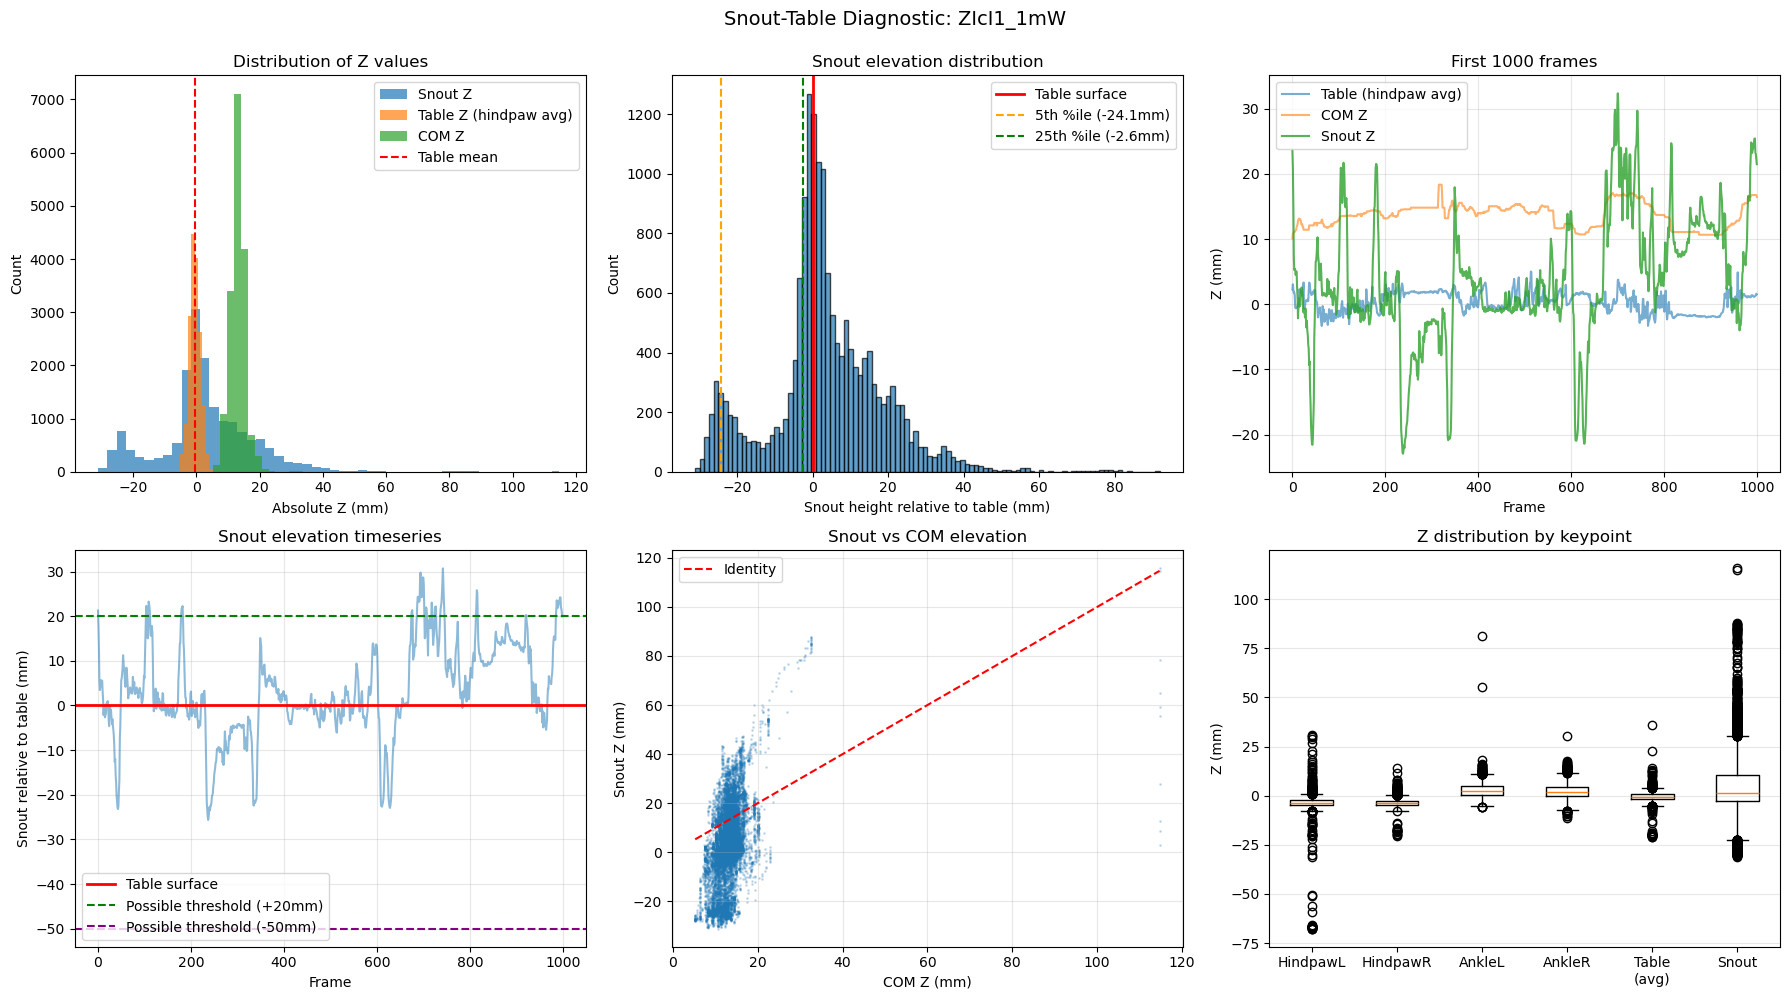

In [21]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from pathlib import Path

def diagnose_snout_table_relationship(base_path, pred_folder='DANNCE/predict00'):
    """
    Create diagnostic plots to help determine appropriate thresholds.
    Shows distribution of snout heights relative to table surface.
    """
    # Load predictions
    pred_path = Path(base_path) / pred_folder / 'save_data_AVG.mat'
    pred_3d = sio.loadmat(pred_path)['pred']
    pred_3d = np.squeeze(pred_3d, axis=1)  # (frames, 3, 22)
    pred_3d = np.transpose(pred_3d, (0, 2, 1))  # (frames, 22, 3)
    
    # Load COM
    com_file = Path(base_path) / pred_folder / 'com3d_used.mat'
    com_data = sio.loadmat(com_file)
    com = com_data['com']
    
    # Truncate to shorter length
    n_frames = min(len(pred_3d), len(com))
    pred_3d = pred_3d[:n_frames]
    com = com[:n_frames]
    
    print(f"Analyzing {n_frames} frames")
    
    # Extract relevant keypoints
    snout_3d = pred_3d[:, KP['Snout'], :]
    snout_z = snout_3d[:, 2]
    com_z = com[:, 2]
    
    # Get all 4 hindlimb keypoints for table estimation
    hindpaw_indices = [KP['HindpawL'], KP['HindpawR'], 
                       KP['AnkleL'], KP['AnkleR']]
    hindpaw_z = pred_3d[:, hindpaw_indices, 2]  # (frames, 4)
    
    # Different table estimates
    table_z_mean = np.mean(hindpaw_z, axis=1)  # average of 4 hindpaws per frame
    table_z_min = np.min(hindpaw_z, axis=1)    # minimum (most conservative)
    table_z_global_mean = np.mean(table_z_mean)
    table_z_global_min = np.percentile(table_z_mean, 5)  # 5th percentile
    
    # Snout relative to different table estimates
    snout_rel_mean = snout_z - table_z_mean
    snout_rel_global = snout_z - table_z_global_mean
    
    print("\n=== Table Surface Estimates ===")
    print(f"Hindpaw Z mean across all frames: {table_z_global_mean:.2f} mm")
    print(f"Hindpaw Z 5th percentile: {table_z_global_min:.2f} mm")
    print(f"Hindpaw Z range: {np.min(table_z_mean):.2f} to {np.max(table_z_mean):.2f} mm")
    
    print("\n=== Snout Statistics ===")
    print(f"Snout Z absolute range: {np.min(snout_z):.2f} to {np.max(snout_z):.2f} mm")
    print(f"Snout relative to table mean: {np.min(snout_rel_mean):.2f} to {np.max(snout_rel_mean):.2f} mm")
    print(f"Snout relative 5th percentile: {np.percentile(snout_rel_mean, 5):.2f} mm")
    print(f"Snout relative 95th percentile: {np.percentile(snout_rel_mean, 95):.2f} mm")
    
    print("\n=== COM Statistics ===")
    print(f"COM Z range: {np.min(com_z):.2f} to {np.max(com_z):.2f} mm")
    
    # Create diagnostic figure
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Panel 1: Absolute Z values
    axes[0, 0].hist(snout_z, bins=50, alpha=0.7, label='Snout Z')
    axes[0, 0].hist(table_z_mean, bins=50, alpha=0.7, label='Table Z (hindpaw avg)')
    axes[0, 0].hist(com_z, bins=50, alpha=0.7, label='COM Z')
    axes[0, 0].axvline(table_z_global_mean, color='red', ls='--', label='Table mean')
    axes[0, 0].legend()
    axes[0, 0].set_xlabel('Absolute Z (mm)')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title('Distribution of Z values')
    
    # Panel 2: Snout relative to table
    axes[0, 1].hist(snout_rel_mean, bins=100, alpha=0.7, edgecolor='black')
    axes[0, 1].axvline(0, color='red', ls='-', lw=2, label='Table surface')
    axes[0, 1].axvline(np.percentile(snout_rel_mean, 5), color='orange', ls='--', 
                      label=f'5th %ile ({np.percentile(snout_rel_mean, 5):.1f}mm)')
    axes[0, 1].axvline(np.percentile(snout_rel_mean, 25), color='green', ls='--',
                      label=f'25th %ile ({np.percentile(snout_rel_mean, 25):.1f}mm)')
    axes[0, 1].legend()
    axes[0, 1].set_xlabel('Snout height relative to table (mm)')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title('Snout elevation distribution')
    
    # Panel 3: Timeseries of Z values
    frames_sample = np.arange(min(1000, n_frames))
    axes[0, 2].plot(frames_sample, table_z_mean[frames_sample], 
                   label='Table (hindpaw avg)', alpha=0.6)
    axes[0, 2].plot(frames_sample, com_z[frames_sample], 
                   label='COM Z', alpha=0.6)
    axes[0, 2].plot(frames_sample, snout_z[frames_sample], 
                   label='Snout Z', alpha=0.8)
    axes[0, 2].legend()
    axes[0, 2].set_xlabel('Frame')
    axes[0, 2].set_ylabel('Z (mm)')
    axes[0, 2].set_title('First 1000 frames')
    axes[0, 2].grid(True, alpha=0.3)
    
    # Panel 4: Snout relative Z timeseries
    axes[1, 0].plot(frames_sample, snout_rel_mean[frames_sample], alpha=0.5)
    axes[1, 0].axhline(0, color='red', ls='-', lw=2, label='Table surface')
    axes[1, 0].axhline(20, color='green', ls='--', label='Possible threshold (+20mm)')
    axes[1, 0].axhline(-50, color='purple', ls='--', label='Possible threshold (-50mm)')
    axes[1, 0].legend()
    axes[1, 0].set_xlabel('Frame')
    axes[1, 0].set_ylabel('Snout relative to table (mm)')
    axes[1, 0].set_title('Snout elevation timeseries')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Panel 5: Scatter - snout vs COM Z
    axes[1, 1].scatter(com_z, snout_z, s=1, alpha=0.2)
    axes[1, 1].plot([com_z.min(), com_z.max()], 
                   [com_z.min(), com_z.max()], 'r--', label='Identity')
    axes[1, 1].set_xlabel('COM Z (mm)')
    axes[1, 1].set_ylabel('Snout Z (mm)')
    axes[1, 1].set_title('Snout vs COM elevation')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Panel 6: Boxplot showing variation
    box_data = [
        hindpaw_z[:, 0], hindpaw_z[:, 1], 
        hindpaw_z[:, 2], hindpaw_z[:, 3],
        table_z_mean, snout_z
    ]
    axes[1, 2].boxplot(box_data, labels=[
        'HindpawL', 'HindpawR', 'AnkleL', 'AnkleR', 
        'Table\n(avg)', 'Snout'
    ])
    axes[1, 2].set_ylabel('Z (mm)')
    axes[1, 2].set_title('Z distribution by keypoint')
    axes[1, 2].grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f'Snout-Table Diagnostic: {Path(base_path).name}', 
                 fontsize=14, y=0.995)
    plt.tight_layout()
    
    # Save
    save_folder = Path(base_path) / 'vis'
    save_folder.mkdir(exist_ok=True)
    save_path = save_folder / 'snout_table_diagnostic.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nSaved diagnostic plot to: {save_path}")
    plt.show()
    
    return {
        'snout_z': snout_z,
        'table_z_mean': table_z_mean,
        'snout_rel_mean': snout_rel_mean,
        'table_z_global_mean': table_z_global_mean,
        'table_z_global_min': table_z_global_min
    }


# Run diagnostic
diag = diagnose_snout_table_relationship(path)

# adding dappy to the picture

In [ ]:
import pickle

def load_clusters_for_session(data_obj_path, rec_path, pred_folder='DANNCE/predict00'):
    """
    Load cluster assignments for a specific recording session.
    
    Returns:
        cluster_labels: array of cluster IDs per frame
        frame_indices: corresponding frame numbers
    """
    # Load the data object
    with open(data_obj_path, 'rb') as f:
        data_obj = pickle.load(f)
    
    # Build the prediction path that matches what's in data_obj
    rec_mat_path = os.path.join(rec_path, pred_folder, "save_data_AVG.mat")
    
    # Filter to this session
    session_data = data_obj.data[data_obj.data["Prediction_path"] == rec_mat_path].copy()
    
    if session_data.empty:
        print(f"WARNING: No data found for {rec_mat_path}")
        print(f"Available paths: {data_obj.data['Prediction_path'].unique()}")
        return None, None
    
    print(f"Found {len(session_data)} frames for this session")
    
    # Get cluster labels - it's 'Cluster' with capital C
    cluster_labels = session_data['Cluster'].to_numpy()
    frame_indices = session_data['frame'].to_numpy()
    
    print(f"Cluster column: 'Cluster'")
    print(f"Number of unique clusters: {len(np.unique(cluster_labels))}")
    print(f"Cluster range: {np.min(cluster_labels)} to {np.max(cluster_labels)}")
    print(f"Frame range: {frame_indices.min()} to {frame_indices.max()}")
    print(f"Frame sampling: every {np.diff(frame_indices).min()} frames")
    
    return cluster_labels, frame_indices


def analyze_snout_with_clusters(base_path, 
                                 data_obj_path,
                                 pred_folder='DANNCE/predict00',
                                 on_table_threshold=15, 
                                 off_edge_threshold=-15):
    """
    Combined analysis: snout behavior + behavioral clusters.
    """
    # First, run the snout analysis
    results = analyze_snout_ground_contact(
        base_path=base_path,
        pred_folder=pred_folder,
        on_table_threshold=on_table_threshold,
        off_edge_threshold=off_edge_threshold
    )
    
    # Load cluster data
    cluster_labels, frame_indices = load_clusters_for_session(
        data_obj_path, base_path, pred_folder
    )
    
    if cluster_labels is None:
        print("Could not load clusters, proceeding without cluster info")
        results['cluster_labels'] = None
        results['cluster_frames'] = None
        return results
    
    # Align clusters with our analysis frames
    # Create a mapping from frame index to cluster
    frame_to_cluster = dict(zip(frame_indices, cluster_labels))
    
    # Get cluster for each frame in our analysis
    n_frames = len(results['snout_z'])
    aligned_clusters = np.full(n_frames, -1, dtype=int)  # -1 for missing
    
    for i in range(n_frames):
        if i in frame_to_cluster:
            aligned_clusters[i] = frame_to_cluster[i]
    
    results['cluster_labels'] = aligned_clusters
    results['cluster_frames'] = frame_indices
    
    # Analyze which clusters correspond to sniffing behaviors
    on_table_mask_with_clusters = results['on_table_mask'] & (aligned_clusters >= 0)
    off_edge_mask_with_clusters = results['off_edge_mask'] & (aligned_clusters >= 0)
    
    on_table_clusters = aligned_clusters[on_table_mask_with_clusters]
    off_edge_clusters = aligned_clusters[off_edge_mask_with_clusters]
    
    print("\n=== Cluster Analysis ===")
    print(f"Frames with cluster labels: {np.sum(aligned_clusters >= 0)} / {n_frames}")
    print(f"On-table frames with clusters: {len(on_table_clusters)} / {np.sum(results['on_table_mask'])}")
    print(f"Off-edge frames with clusters: {len(off_edge_clusters)} / {np.sum(results['off_edge_mask'])}")
    
    if len(on_table_clusters) > 0:
        unique_on, counts_on = np.unique(on_table_clusters, return_counts=True)
        print(f"\nTop on-table sniffing clusters:")
        for clust, cnt in sorted(zip(unique_on, counts_on), key=lambda x: -x[1])[:5]:
            print(f"  Cluster {clust}: {cnt} frames ({100*cnt/len(on_table_clusters):.1f}%)")
    
    if len(off_edge_clusters) > 0:
        unique_off, counts_off = np.unique(off_edge_clusters, return_counts=True)
        print(f"\nTop off-edge peeking clusters:")
        for clust, cnt in sorted(zip(unique_off, counts_off), key=lambda x: -x[1])[:5]:
            print(f"  Cluster {clust}: {cnt} frames ({100*cnt/len(off_edge_clusters):.1f}%)")
    
    return results


def plot_snout_clusters_focused(results, base_path, vis_dir='vis'):
    """
    Focused visualization on the key sniffing-related clusters.
    """
    if results['cluster_labels'] is None:
        print("No cluster data available")
        return
    
    cluster_labels = results['cluster_labels']
    has_label = cluster_labels >= 0
    
    # Get top clusters for each behavior
    on_table_clusters = cluster_labels[results['on_table_mask'] & has_label]
    off_edge_clusters = cluster_labels[results['off_edge_mask'] & has_label]
    
    unique_on, counts_on = np.unique(on_table_clusters, return_counts=True)
    unique_off, counts_off = np.unique(off_edge_clusters, return_counts=True)
    
    # Top 5 clusters for each behavior
    top_on = sorted(zip(unique_on, counts_on), key=lambda x: -x[1])[:5]
    top_off = sorted(zip(unique_off, counts_off), key=lambda x: -x[1])[:5]
    
    top_on_ids = [c for c, _ in top_on]
    top_off_ids = [c for c, _ in top_off]
    
    print("\n=== Focused Cluster Analysis ===")
    print("Top 5 on-table sniffing clusters:", top_on_ids)
    print("Top 5 off-edge peeking clusters:", top_off_ids)
    
    # Create figure
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # --- Row 1: Summary statistics ---
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])
    
    # Panel 1: Bar chart of top on-table clusters
    on_ids = [c for c, _ in top_on]
    on_counts = [cnt for _, cnt in top_on]
    ax1.bar(range(len(on_ids)), on_counts, color='green', alpha=0.7)
    ax1.set_xticks(range(len(on_ids)))
    ax1.set_xticklabels([f'C{c}' for c in on_ids])
    ax1.set_ylabel('Frame count')
    ax1.set_title('Top 5 On-Table Sniffing Clusters')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Panel 2: Bar chart of top off-edge clusters
    off_ids = [c for c, _ in top_off]
    off_counts = [cnt for _, cnt in top_off]
    ax2.bar(range(len(off_ids)), off_counts, color='purple', alpha=0.7)
    ax2.set_xticks(range(len(off_ids)))
    ax2.set_xticklabels([f'C{c}' for c in off_ids])
    ax2.set_ylabel('Frame count')
    ax2.set_title('Top 5 Off-Edge Peeking Clusters')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Panel 3: Pie chart showing behavior distribution
    behavior_counts = [
        np.sum(results['on_table_mask']),
        np.sum(results['off_edge_mask']),
        len(results['snout_z']) - np.sum(results['on_table_mask']) - np.sum(results['off_edge_mask'])
    ]
    ax3.pie(behavior_counts, labels=['On-table\nsniff', 'Off-edge\npeek', 'Other'],
           colors=['green', 'purple', 'lightgray'], autopct='%1.1f%%')
    ax3.set_title('Overall Behavior Distribution')
    
    # --- Row 2: Spatial maps for top clusters ---
    com_xy = results['com_xy']
    
    # Fit circle once
    hull = ConvexHull(com_xy)
    hx, hy = com_xy[hull.vertices, 0], com_xy[hull.vertices, 1]
    def residuals(params, xh, yh):
        return np.hypot(xh - params[0], yh - params[1]) - params[2]
    init = [hx.mean(), hy.mean(), np.mean(np.hypot(hx - hx.mean(), hy - hy.mean()))]
    res = least_squares(residuals, init, args=(hx, hy))
    xc, yc, r = res.x
    theta = np.linspace(0, 2*np.pi, 200)
    
    # Panel 4: Spatial map - top on-table clusters only
    ax4 = fig.add_subplot(gs[1, :])
    ax4.plot(xc + r*np.cos(theta), yc + r*np.sin(theta), 'k-', lw=2, alpha=0.5)
    ax4.scatter(com_xy[:, 0], com_xy[:, 1], s=1, alpha=0.05, c='gray', label='All COM')
    
    colors_on = plt.cm.Greens(np.linspace(0.4, 0.9, len(top_on_ids)))
    for i, clust_id in enumerate(top_on_ids):
        mask = (cluster_labels == clust_id) & results['on_table_mask']
        if np.sum(mask) > 0:
            ax4.scatter(com_xy[mask, 0], com_xy[mask, 1], 
                       s=30, c=[colors_on[i]], alpha=0.8,
                       edgecolors='darkgreen', linewidths=1,
                       label=f'C{clust_id} (n={np.sum(mask)})')
    
    ax4.set_aspect('equal')
    ax4.set_title('Spatial Distribution: Top On-Table Sniffing Clusters')
    ax4.set_xlabel('X (mm)')
    ax4.set_ylabel('Y (mm)')
    ax4.legend(loc='upper right', fontsize=9)
    ax4.grid(True, alpha=0.3)
    
    # Panel 5: Spatial map - top off-edge clusters only
    ax5 = fig.add_subplot(gs[2, :])
    ax5.plot(xc + r*np.cos(theta), yc + r*np.sin(theta), 'k-', lw=2, alpha=0.5)
    ax5.scatter(com_xy[:, 0], com_xy[:, 1], s=1, alpha=0.05, c='gray', label='All COM')
    
    colors_off = plt.cm.Purples(np.linspace(0.4, 0.9, len(top_off_ids)))
    for i, clust_id in enumerate(top_off_ids):
        mask = (cluster_labels == clust_id) & results['off_edge_mask']
        if np.sum(mask) > 0:
            ax5.scatter(com_xy[mask, 0], com_xy[mask, 1], 
                       s=30, c=[colors_off[i]], alpha=0.8, marker='s',
                       edgecolors='indigo', linewidths=1,
                       label=f'C{clust_id} (n={np.sum(mask)})')
    
    ax5.set_aspect('equal')
    ax5.set_title('Spatial Distribution: Top Off-Edge Peeking Clusters')
    ax5.set_xlabel('X (mm)')
    ax5.set_ylabel('Y (mm)')
    ax5.legend(loc='upper right', fontsize=9)
    ax5.grid(True, alpha=0.3)
    
    plt.suptitle(f'{Path(base_path).name} - Focused Cluster Analysis', fontsize=16, y=0.995)
    
    # Save
    save_folder = Path(base_path) / vis_dir
    save_folder.mkdir(exist_ok=True)
    save_path = save_folder / 'snout_clusters_focused.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nSaved focused cluster plot to: {save_path}")
    plt.close()
    
    # Print summary for next steps
    print("\n=== Next Steps ===")
    print("Look at these cluster videos to understand the behaviors:")
    print("On-table sniffing clusters:", top_on_ids)
    print("Off-edge peeking clusters:", top_off_ids)

def plot_snout_analysis_with_clusters(results, base_path, vis_dir='vis'):
    """
    Enhanced visualization with cluster overlay.
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    has_clusters = results['cluster_labels'] is not None
    
    # Panel 1: Z-height timeseries with clusters
    frames = np.arange(len(results['snout_z']))
    
    if has_clusters:
        # Color by cluster
        cluster_labels = results['cluster_labels']
        unique_clusters = np.unique(cluster_labels[cluster_labels >= 0])
        n_clusters = len(unique_clusters)
        colors = plt.cm.tab20(np.linspace(0, 1, n_clusters))
        
        # Plot by cluster
        for i, clust in enumerate(unique_clusters):
            mask = cluster_labels == clust
            axes[0].scatter(frames[mask], results['snout_relative_z'][mask], 
                          s=2, alpha=0.5, c=[colors[i]], label=f'C{clust}' if i < 10 else '')
    else:
        axes[0].plot(frames, results['snout_relative_z'], alpha=0.5, linewidth=0.5)
    
    axes[0].axhline(0, color='brown', ls='-', lw=2, label='Table')
    axes[0].axhline(results['on_table_threshold'], color='green', ls='--')
    axes[0].axhline(results['off_edge_threshold'], color='purple', ls='--')
    axes[0].set_xlabel('Frame')
    axes[0].set_ylabel('Snout relative to table (mm)')
    axes[0].set_title('Snout elevation colored by cluster')
    if has_clusters and n_clusters <= 10:
        axes[0].legend(fontsize=8, ncol=2)
    axes[0].grid(True, alpha=0.3)
    
    # Panel 2: Spatial map with clusters
    com_xy = results['com_xy']
    
    # Fit circle
    hull = ConvexHull(com_xy)
    hx, hy = com_xy[hull.vertices, 0], com_xy[hull.vertices, 1]
    
    def residuals(params, xh, yh):
        return np.hypot(xh - params[0], yh - params[1]) - params[2]
    
    init = [hx.mean(), hy.mean(), 
            np.mean(np.hypot(hx - hx.mean(), hy - hy.mean()))]
    res = least_squares(residuals, init, args=(hx, hy))
    xc, yc, r = res.x
    
    # Plot circle
    theta = np.linspace(0, 2*np.pi, 200)
    axes[1].plot(xc + r*np.cos(theta), yc + r*np.sin(theta),
                'b-', lw=2, label='Arena', alpha=0.7)
    
    # Plot COM colored by cluster or behavior
    if has_clusters:
        cluster_labels = results['cluster_labels']
        for i, clust in enumerate(unique_clusters):
            mask = cluster_labels == clust
            axes[1].scatter(com_xy[mask, 0], com_xy[mask, 1], 
                          s=3, alpha=0.3, c=[colors[i]], label=f'C{clust}' if i < 10 else '')
    else:
        axes[1].scatter(com_xy[:, 0], com_xy[:, 1], s=2, alpha=0.1, c='gray')
    
    # Overlay sniffing events
    on_table_xy = results['on_table_locations']
    off_edge_xy = results['off_edge_locations']
    
    if len(on_table_xy) > 0:
        axes[1].scatter(on_table_xy[:, 0], on_table_xy[:, 1], s=30, 
                       c='green', alpha=0.8, marker='o', 
                       edgecolors='darkgreen', linewidths=1,
                       label='On-table sniff')
    
    if len(off_edge_xy) > 0:
        axes[1].scatter(off_edge_xy[:, 0], off_edge_xy[:, 1], s=30, 
                       c='purple', alpha=0.8, marker='s',
                       edgecolors='indigo', linewidths=1,
                       label='Off-edge peek')
    
    axes[1].set_aspect('equal')
    axes[1].set_title('Spatial distribution by cluster + sniffing')
    axes[1].set_xlabel('X (mm)')
    axes[1].set_ylabel('Y (mm)')
    if has_clusters and n_clusters <= 10:
        axes[1].legend(fontsize=7, ncol=2)
    else:
        axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)
    
    # Panel 3: Cluster composition for sniffing behaviors
    if has_clusters:
        on_table_clusters = results['cluster_labels'][results['on_table_mask']]
        off_edge_clusters = results['cluster_labels'][results['off_edge_mask']]
        
        on_table_clusters = on_table_clusters[on_table_clusters >= 0]
        off_edge_clusters = off_edge_clusters[off_edge_clusters >= 0]
        
        unique_on, counts_on = np.unique(on_table_clusters, return_counts=True)
        unique_off, counts_off = np.unique(off_edge_clusters, return_counts=True)
        
        # Bar plot
        x_pos = np.arange(len(unique_clusters))
        on_heights = [np.sum(counts_on[unique_on == c]) if c in unique_on else 0 
                     for c in unique_clusters]
        off_heights = [np.sum(counts_off[unique_off == c]) if c in unique_off else 0 
                      for c in unique_clusters]
        
        width = 0.35
        axes[2].bar(x_pos - width/2, on_heights, width, label='On-table', color='green', alpha=0.7)
        axes[2].bar(x_pos + width/2, off_heights, width, label='Off-edge', color='purple', alpha=0.7)
        
        axes[2].set_xlabel('Cluster ID')
        axes[2].set_ylabel('Frame count')
        axes[2].set_title('Cluster composition of sniffing behaviors')
        axes[2].set_xticks(x_pos)
        axes[2].set_xticklabels([f'C{c}' for c in unique_clusters])
        axes[2].legend()
        axes[2].grid(True, alpha=0.3, axis='y')
    else:
        axes[2].text(0.5, 0.5, 'No cluster data available', 
                    ha='center', va='center', transform=axes[2].transAxes)
        axes[2].set_title('Cluster analysis')
    
    plt.suptitle(f'{Path(base_path).name}', fontsize=14, y=0.995)
    plt.tight_layout()
    
    # Save
    save_folder = Path(base_path) / vis_dir
    save_folder.mkdir(exist_ok=True)
    save_path = save_folder / 'snout_analysis_with_clusters.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nSaved cluster analysis plot to: {save_path}")
    plt.show()

In [12]:
import site

# this both inserts the directory *and* processes any .pth files in it
site.addsitedir(
    "/home/lq53/miniconda3/envs/neuroposelib/lib/python3.9/site-packages"
)

# now Python has read __editable__.neuroposelib-0.2.dev0.pth
# and added your repo path automatically.
import neuroposelib
print("✅ loaded from:", neuroposelib.__file__)


✅ loaded from: /home/lq53/mir_repos/dappy_24_nov/neuroposelib/src/neuroposelib/__init__.py


In [23]:
data_obj_path = "/home/lq53/mir_repos/dappy_24_nov/251105_allrun_for_renzhi_lumi/251105pos_ang/datastruct.p"

results = analyze_snout_with_clusters(
    base_path=path,
    data_obj_path=data_obj_path,
    pred_folder='DANNCE/predict00',
    on_table_threshold=15,
    off_edge_threshold=-15
)

plot_snout_clusters_focused(results, base_path=path, vis_dir='vis')

Using 17000 frames with 22 keypoints

Estimated table surface Z: -2.56 mm
Table Z range: -21.02 to 35.92 mm
Snout Z range: -31.12 to 115.71 mm
COM Z range: 5.30 to 114.69 mm
Snout relative Z range: -31.04 to 91.85 mm

On-table sniffing: 7108 frames (41.8%)
Off-edge peeking: 2008 frames (11.8%)
Found 1700 frames for this session
Cluster column: 'Cluster'
Number of unique clusters: 59
Cluster range: 4 to 108
Frame range: 0 to 16990
Frame sampling: every 10 frames

=== Cluster Analysis ===
Frames with cluster labels: 1700 / 17000
On-table frames with clusters: 710 / 7108
Off-edge frames with clusters: 199 / 2008

Top on-table sniffing clusters:
  Cluster 58: 52 frames (7.3%)
  Cluster 54: 48 frames (6.8%)
  Cluster 61: 46 frames (6.5%)
  Cluster 75: 45 frames (6.3%)
  Cluster 73: 42 frames (5.9%)

Top off-edge peeking clusters:
  Cluster 6: 26 frames (13.1%)
  Cluster 19: 19 frames (9.5%)
  Cluster 47: 19 frames (9.5%)
  Cluster 21: 15 frames (7.5%)
  Cluster 53: 15 frames (7.5%)

=== Foc

In [14]:
# Quick diagnostic to see what's in the data
import pickle

with open("/home/lq53/mir_repos/dappy_24_nov/251105_allrun_for_renzhi_lumi/251105pos_ang/datastruct.p", 'rb') as f:
    data_obj = pickle.load(f)

print("Data object attributes:")
print(dir(data_obj))
print("\nDataFrame columns:")
print(data_obj.data.columns.tolist())
print("\nDataFrame shape:")
print(data_obj.data.shape)
print("\nSample of first few rows:")
print(data_obj.data.head())

# Check for cluster info
rec_mat_path = os.path.join(path, "DANNCE/predict00/save_data_AVG.mat")
session_data = data_obj.data[data_obj.data["Prediction_path"] == rec_mat_path]
print(f"\nSession data shape: {session_data.shape}")
if not session_data.empty:
    print("Session columns:")
    print(session_data.columns.tolist())

Data object attributes:
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_props', 'check_reset_data', 'connectivity', 'data', 'downsample', 'embed_vals', 'feat_shape', 'feature_labels', 'features', 'frame', 'get_frequencies', 'id', 'meta', 'meta_by_frame', 'meta_unique', 'n_frames', 'pose', 'write_pickle', 'ws']

DataFrame columns:
['id', 'frame', 'AnimalID', 'Sex', 'Condition', 'date', 'time', 'Prediction_path', 'miniscope', 'after_oxytocin', 'before_oxytocin', 'social', 'habituation', 'saline', 'test', 'caffeine', 'cricket', 'baseline', 'recording_time', 'features', 'embed_vals', 'Cluster']

DataFrame shape:
(430800, 22)

Sample of first few rows:
    id  frame   AnimalID   Sex